# EmotionCLIP-ReID — Landmark Build Notebook

Notebook độc lập này chỉ chuẩn bị landmark/anatomy artifact cho FER2013 và RAF-DB. Chạy notebook này trước các notebook train; sau khi build xong, notebook train chỉ đọc `manifest_anatomy.jsonl` và không chạy detector lại.

Mỗi lần build có `LANDMARK_RUN_ID` theo ngày giờ. Artifact dataset được cache riêng theo hash manifest, model, schema và tham số jitter; log/audit/ảnh preview của lần build nằm trong `outputs/landmark_build/<LANDMARK_RUN_ID>/`.


## 0. Clone hoặc cập nhật source `old_branch`

Generator landmark nằm trong branch `old_branch` của EmotionCLIP-ReID. Cell này không clone một detector repo thứ hai; MediaPipe chỉ được cài như runtime package và model task được tải một lần.


In [1]:
from pathlib import Path
import os
import subprocess
import sys

# Có thể đặt EMOTIONCLIP_REPO nếu notebook chạy ngoài thư mục repo.
# Nếu không đặt, notebook tự tìm repo từ thư mục hiện tại và các thư mục cha.
REPO_OVERRIDE = os.environ.get('EMOTIONCLIP_REPO', '').strip()
if REPO_OVERRIDE:
    REPO_DIR = Path(REPO_OVERRIDE).expanduser().resolve()
else:
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    REPO_DIR = next(
        (candidate for candidate in candidates
         if (candidate / 'train_emotionclip.py').is_file()
         and (candidate / 'utils').is_dir()),
        None,
    )
    if REPO_DIR is None:
        # `/home/...` is valid on JupyterHub Linux only; it becomes
        # `E:\home\...` on Windows and points to the wrong checkout.
        JUPYTER_WORKSPACE = (
            Path('/home/jupyter-hault') if os.name != 'nt'
            else Path.home() / 'jupyter-hault'
        )
        REPO_DIR = JUPYTER_WORKSPACE / 'EmotionCLIP-ReID'
GIT_REPO_URL = 'https://github.com/haulth/EmotionCLIP-ReID.git'
REPO_BRANCH = 'old_branch'

REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
if (REPO_DIR / '.git').exists():
    commands = [
        ['git', '-C', str(REPO_DIR), 'fetch', 'origin', REPO_BRANCH],
        ['git', '-C', str(REPO_DIR), 'checkout', REPO_BRANCH],
        ['git', '-C', str(REPO_DIR), 'pull', '--ff-only', 'origin', REPO_BRANCH],
    ]
else:
    commands = [[
        'git', 'clone', '-b', REPO_BRANCH, '--single-branch', GIT_REPO_URL, str(REPO_DIR)
    ]]
for command in commands:
    print('Running:', ' '.join(command))
    completed = subprocess.run(command, text=True, capture_output=True, check=True)
    if completed.stdout.strip():
        print(completed.stdout.strip())

os.chdir(REPO_DIR)
# Jupyter giữ sys.path của kernel lúc khởi động; đổi cwd không đủ để
# import được `utils.*` từ repo vừa chọn.
repo_path = str(REPO_DIR)
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)
branch = subprocess.check_output(
    ['git', '-C', str(REPO_DIR), 'branch', '--show-current'], text=True
).strip()
assert branch == REPO_BRANCH, f'Expected {REPO_BRANCH}, got {branch}'
REPO = REPO_DIR.resolve()
print('Repo:', REPO)
print('Branch:', branch)
print('Python:', sys.executable)


Running: git -C /home/jupyter-hault/EmotionCLIP-ReID fetch origin old_branch
Running: git -C /home/jupyter-hault/EmotionCLIP-ReID checkout old_branch
Your branch is up to date with 'origin/old_branch'.
Running: git -C /home/jupyter-hault/EmotionCLIP-ReID pull --ff-only origin old_branch
Already up to date.
Repo: /home/jupyter-hault/EmotionCLIP-ReID
Branch: old_branch
Python: /opt/tljh/user/envs/py310/bin/python


## 1. Package và run context

Model task chính thức của MediaPipe được lưu trong `data/models/mediapipe/face_landmarker.task`; nếu file đã tồn tại notebook không tải lại. `FORCE_REBUILD=False` là chế độ bình thường.


In [ ]:
from datetime import datetime
from pathlib import Path
import importlib.util
import subprocess
import sys

from utils.notebook_run import timestamped_run_id

if importlib.util.find_spec('mediapipe') is None:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q', 'mediapipe>=0.10.30,<0.11'
    ])

SEED = 42
BUILD_FER2013 = True
BUILD_RAFDB = True
FORCE_REBUILD = False
LANDMARK_JITTER_REPEATS = 4
LANDMARK_JITTER_PIXELS = 2

# ===== PATH DATA CHỈNH TRỰC TIẾP TẠI ĐÂY =====
DATA_DIR = (REPO / 'data').resolve()
FER2013_DATA_DIR = (DATA_DIR / 'hf_fer2013').resolve()
RAFDB_DATA_DIR = (DATA_DIR / 'RAF-DB').resolve()
FER2013_MANIFEST = FER2013_DATA_DIR / 'manifest.jsonl'
FER2013_ANATOMY_MANIFEST = FER2013_DATA_DIR / 'manifest_anatomy.jsonl'
FER2013_ANATOMY_DIR = FER2013_DATA_DIR / 'anatomy_v3'
RAFDB_MANIFEST = RAFDB_DATA_DIR / 'manifest.jsonl'
RAFDB_ANATOMY_MANIFEST = RAFDB_DATA_DIR / 'manifest_anatomy.jsonl'
RAFDB_ANATOMY_DIR = RAFDB_DATA_DIR / 'anatomy_v3'
LANDMARK_MODEL_URL = (
    'https://storage.googleapis.com/mediapipe-models/face_landmarker/'
    'face_landmarker/float16/latest/face_landmarker.task'
)
LANDMARK_MODEL_PATH = DATA_DIR / 'models/mediapipe/face_landmarker.task'
LANDMARK_STARTED_AT = datetime.now().astimezone()
LANDMARK_RUN_ID = timestamped_run_id('landmarks', seed=SEED, now=LANDMARK_STARTED_AT)
LANDMARK_RUN_DIR = REPO / 'outputs' / 'landmark_build' / LANDMARK_RUN_ID
LANDMARK_RUN_DIR.mkdir(parents=True, exist_ok=False)

DATASETS = {
    'fer2013': {
        'data_dir': FER2013_DATA_DIR,
        'manifest': FER2013_MANIFEST,
        'root_dir': FER2013_DATA_DIR / 'images',
        'output_manifest': FER2013_ANATOMY_MANIFEST,
        'artifact_root': FER2013_ANATOMY_DIR,
    },
    'rafdb': {
        'data_dir': RAFDB_DATA_DIR,
        'manifest': RAFDB_MANIFEST,
        'root_dir': RAFDB_DATA_DIR,
        'output_manifest': RAFDB_ANATOMY_MANIFEST,
        'artifact_root': RAFDB_ANATOMY_DIR,
    },
}

print('LANDMARK_RUN_ID:', LANDMARK_RUN_ID)
print('LANDMARK_RUN_DIR:', LANDMARK_RUN_DIR)
print('Model:', LANDMARK_MODEL_PATH)
for name, spec in DATASETS.items():
    print(name, 'data_dir:', spec['data_dir'])
    print(name, 'base manifest:', spec['manifest'])
    print(name, 'anatomy manifest:', spec['output_manifest'])
    print(name, 'anatomy artifacts:', spec['artifact_root'])


## 2. Tải model một lần và build cache

Cell này tạo output manifest cho từng dataset được bật. Nếu cache hợp lệ, kết quả trả về `cache_hit=True` và detector không được chạy lại. Nếu đổi model/schema/jitter hoặc muốn ép tạo lại, bật `FORCE_REBUILD=True`.


In [ ]:
import json
import shutil
from pathlib import Path

from utils.notebook_landmarks import (
    download_once,
    prepare_cached_landmarks,
    validate_landmark_manifest_layout,
)

model_path, model_downloaded = download_once(LANDMARK_MODEL_URL, LANDMARK_MODEL_PATH)
print('Model downloaded now:', model_downloaded)

enabled = {
    'fer2013': BUILD_FER2013,
    'rafdb': BUILD_RAFDB,
}
build_results = {}

for name, spec in DATASETS.items():
    if not enabled[name]:
        continue
    for key in ('manifest', 'root_dir'):
        if not Path(spec[key]).exists():
            raise FileNotFoundError(f"{name}: missing {key}: {spec[key]}")
    print(f'\n=== Building {name} ===')
    build_log = LANDMARK_RUN_DIR / f'{name}_build.log'
    result = prepare_cached_landmarks(
        repo_root=REPO,
        manifest=spec['manifest'],
        output_manifest=spec['output_manifest'],
        artifact_root=spec['artifact_root'],
        model_path=model_path,
        root_dir=spec['root_dir'],
        jitter_repeats=LANDMARK_JITTER_REPEATS,
        jitter_pixels=LANDMARK_JITTER_PIXELS,
        seed=SEED,
        force_rebuild=FORCE_REBUILD,
        python_executable=sys.executable,
        log_path=build_log,
    )
    layout_report = validate_landmark_manifest_layout(
        spec['output_manifest'], spec['data_dir']
    )
    result['layout_validation'] = layout_report
    build_results[name] = result
    print('cache_hit:', result['cache_hit'])
    print('output_manifest:', result['output_manifest'])
    print('artifacts:', result['artifact_count'], '/', result['record_count'])
    print('layout:', layout_report)

summary_path = LANDMARK_RUN_DIR / 'build_summary.json'
summary_path.write_text(
    json.dumps(
        {
            'run_id': LANDMARK_RUN_ID,
            'started_at': LANDMARK_STARTED_AT.isoformat(),
            'model_path': str(model_path),
            'model_downloaded_now': model_downloaded,
            'force_rebuild': FORCE_REBUILD,
            'jitter_repeats': LANDMARK_JITTER_REPEATS,
            'jitter_pixels': LANDMARK_JITTER_PIXELS,
            'datasets': build_results,
        },
        indent=2,
        ensure_ascii=False,
    ),
    encoding='utf-8',
)
print('Summary:', summary_path)


## 3. Audit coverage và geometry

Audit được lưu riêng theo `LANDMARK_RUN_ID`. Hãy kiểm tra detection/usable coverage trước khi bật anatomy routing; coverage thấp không được che bằng cách tự điền landmark giả.


In [4]:
import json
import subprocess

audit_results = {}
for name, spec in DATASETS.items():
    if not enabled[name]:
        continue
    audit_path = LANDMARK_RUN_DIR / f'{name}_anatomy_audit_all.json'
    audit_log = LANDMARK_RUN_DIR / f'{name}_audit.log'
    command = [
        sys.executable,
        'tools/audit_anatomy_geometry.py',
        '--manifest', str(spec['output_manifest']),
        '--root-dir', str(spec['root_dir']),
        '--split', 'all',
        '--output', str(audit_path),
    ]
    completed = subprocess.run(
        command,
        cwd=REPO,
        capture_output=True,
        text=True,
        check=False,
    )
    audit_log.write_text(
        (completed.stdout or '') + (completed.stderr or ''),
        encoding='utf-8',
    )
    if completed.stdout:
        print(completed.stdout, end='')
    if completed.returncode:
        raise subprocess.CalledProcessError(
            completed.returncode, command, output=completed.stdout, stderr=completed.stderr
        )
    report = json.loads(audit_path.read_text(encoding='utf-8'))
    audit_results[name] = report
    print(name, 'coverage:', {
        split: payload.get('detection_coverage')
        for split, payload in report.get('splits', {}).items()
    })

(LANDMARK_RUN_DIR / 'audit_summary.json').write_text(
    json.dumps(audit_results, indent=2, ensure_ascii=False), encoding='utf-8'
)
print('Audit summary:', LANDMARK_RUN_DIR / 'audit_summary.json')


wrote=/home/jupyter-hault/EmotionCLIP-ReID/outputs/landmark_build/landmarks-20260718T235715.985262+0700-seed42/fer2013_anatomy_audit_all.json
samples=35887 detected=30536 detection_rate=0.8509
fer2013 coverage: {}
wrote=/home/jupyter-hault/EmotionCLIP-ReID/outputs/landmark_build/landmarks-20260718T235715.985262+0700-seed42/rafdb_anatomy_audit_all.json
samples=15339 detected=13205 detection_rate=0.8609
rafdb coverage: {}
Audit summary: /home/jupyter-hault/EmotionCLIP-ReID/outputs/landmark_build/landmarks-20260718T235715.985262+0700-seed42/audit_summary.json


## 4. Visual preview landmark

Ảnh preview được lưu trong thư mục build run, không lẫn vào output của training.


Saved: /home/jupyter-hault/EmotionCLIP-ReID/outputs/landmark_build/landmarks-20260718T235715.985262+0700-seed42/fer2013_landmark_preview.png


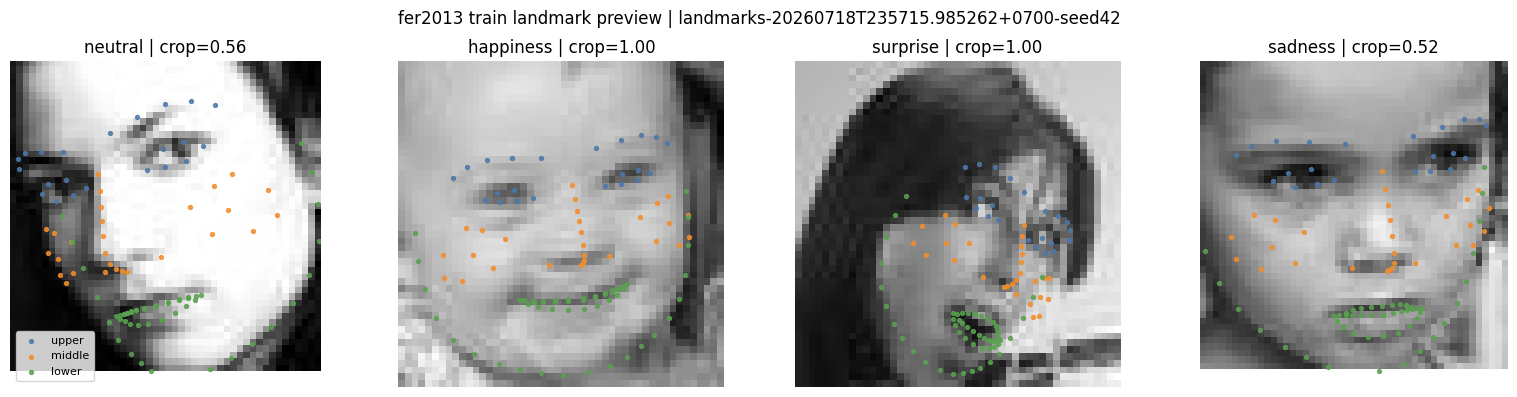

Saved: /home/jupyter-hault/EmotionCLIP-ReID/outputs/landmark_build/landmarks-20260718T235715.985262+0700-seed42/rafdb_landmark_preview.png


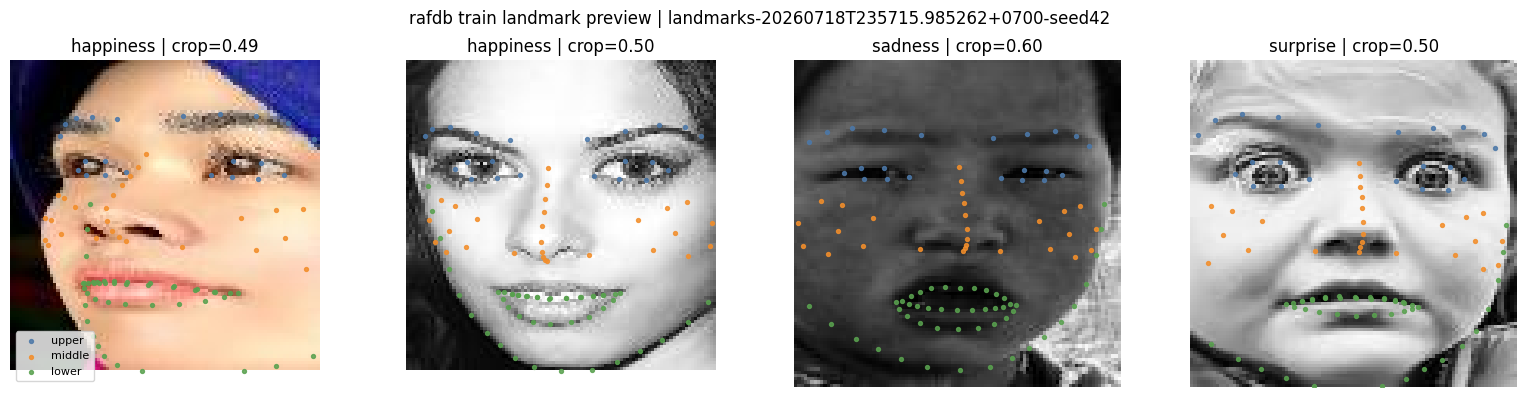

298

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from datasets.anatomy import MEDIAPIPE_GROUPS, REGION_GROUPS, load_anatomy_artifact
from datasets.emotion_manifest import load_emotion_manifest

region_colors = {'upper': '#4C78A8', 'middle': '#F28E2B', 'lower': '#59A14F'}
preview_paths = {}

for name, spec in DATASETS.items():
    if not enabled[name]:
        continue
    samples = load_emotion_manifest(
        str(spec['output_manifest']), root_dir=str(spec['root_dir']), split='train'
    )
    selected = []
    for sample in samples:
        artifact = load_anatomy_artifact(sample.landmark_path) if sample.landmark_path else None
        if artifact and (artifact.get('detector') or {}).get('detected'):
            selected.append((sample, artifact))
        if len(selected) >= 4:
            break

    fig, axes = plt.subplots(
        1, max(1, len(selected)), figsize=(4 * max(1, len(selected)), 4)
    )
    axes = np.atleast_1d(axes).ravel()
    if not selected:
        axes[0].text(0.5, 0.5, 'No detected landmark sample', ha='center', va='center')
        axes[0].axis('off')
    for ax, (sample, artifact) in zip(axes, selected):
        image = Image.open(sample.image_path).convert('RGB')
        ax.imshow(image)
        width, height = image.size
        landmarks = artifact.get('landmarks') or []
        for region, groups in REGION_GROUPS.items():
            indices = sorted({index for group in groups for index in MEDIAPIPE_GROUPS[group]})
            points = [
                landmarks[index]
                for index in indices
                if index < len(landmarks) and landmarks[index].get('valid', True)
            ]
            if points:
                ax.scatter(
                    [point['x'] * width for point in points],
                    [point['y'] * height for point in points],
                    s=8, alpha=0.85, label=region, color=region_colors[region]
                )
        ax.set_title(f'{sample.emotion} | crop={artifact.get("crop_quality", 0):.2f}')
        ax.axis('off')
    if selected:
        axes[0].legend(loc='lower left', fontsize=8)
    fig.suptitle(f'{name} train landmark preview | {LANDMARK_RUN_ID}')
    plt.tight_layout()
    preview_path = LANDMARK_RUN_DIR / f'{name}_landmark_preview.png'
    fig.savefig(preview_path, dpi=180, bbox_inches='tight')
    preview_paths[name] = str(preview_path)
    print('Saved:', preview_path)
    plt.show()

(LANDMARK_RUN_DIR / 'preview_summary.json').write_text(
    json.dumps(preview_paths, indent=2, ensure_ascii=False), encoding='utf-8'
)


## 5. Training handoff

Sau khi cell trên thành công, hai notebook train dùng các manifest sau:

- `data/hf_fer2013/manifest_anatomy.jsonl`
- `data/RAF-DB/manifest_anatomy.jsonl`

Không bật `FORCE_REBUILD` trong notebook train; chỉ chạy lại notebook này khi dataset, model hoặc tham số landmark thay đổi.
